In [1]:
# Compare condition-specific CV fit parameters to standard full-fit parameters by ROI
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import cortex as cx

from prf_expect.utils import io
from prf_expect.utils.beh import calculate_visual_angle

settings = io.load_settings()
data_dir = Path(settings["general"]["data_dir"]) / "data"
space = settings["mri"]["space"]

r2_thre = globals().get("r2_thre", 0.3)
half_vis_angle = globals().get(
    "half_vis_angle",
    calculate_visual_angle(
        settings["monitor"]["screen_size_cm"][1],
        settings["monitor"]["screen_distance_cm"],
    )
    / 2,
 )

params_of_interest = [
    "x",
    "y",
    "prf_size",
    "prf_ampl",
    "surr_ampl",
    "surr_size",
    "neur_bsl",
    "surr_bsl",
]
conditions = ("omission", "sparse", "violation")
subjects = list(settings["general"]["subject_list"])
print(f"Subjects: {len(subjects)} | Conditions: {conditions}")

Loading settings from /gpfs/home6/nwang/software/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml
Subjects: 7 | Conditions: ('omission', 'sparse', 'violation')


In [2]:
# ROI setup (combined ROIs, same convention used in out-of-sample-test)
if "rois" not in globals():
    ROIs_list_long = (
        "V1",
        "V2",
        "V3",
        "V3A",
        "V3B",
        "V4",
        "LO1",
        "LO2",
        "VO1",
        "VO2",
        "hMT",
        "MST",
        "IPS0",
        "IPS1",
        "IPS2",
        "IPS3",
        "IPS4",
        "IPS5",
    )
    roi_verts = cx.get_roi_verts("fsaverage", ROIs_list_long)

    combined_roi_verts = {}
    combined_roi_verts["V1"] = roi_verts["V1"]
    combined_roi_verts["V2"] = roi_verts["V2"]
    combined_roi_verts["V3"] = roi_verts["V3"]
    combined_roi_verts["V3AB"] = np.concatenate((roi_verts["V3A"], roi_verts["V3B"]))
    combined_roi_verts["V4"] = roi_verts["V4"]
    combined_roi_verts["LO"] = np.concatenate((roi_verts["LO1"], roi_verts["LO2"]))
    combined_roi_verts["TO"] = np.concatenate((roi_verts["hMT"], roi_verts["MST"]))
    combined_roi_verts["VO"] = np.concatenate((roi_verts["VO1"], roi_verts["VO2"]))
    combined_roi_verts["earlyIPS"] = np.concatenate(
        (
            roi_verts["IPS0"],
            roi_verts["IPS1"],
            roi_verts["IPS2"],
        )
    )
    combined_roi_verts["lateIPS"] = np.concatenate(
        (
            roi_verts["IPS3"],
            roi_verts["IPS4"],
            roi_verts["IPS5"],
        )
    )
    rois = combined_roi_verts

ROIs_list = list(rois.keys())
print(f"ROIs: {ROIs_list}")

ROIs: ['V1', 'V2', 'V3', 'V3AB', 'V4', 'LO', 'TO', 'VO', 'earlyIPS', 'lateIPS']


In [3]:
def _nansem(values):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size <= 1:
        return np.nan
    return np.nanstd(vals, ddof=1) / np.sqrt(vals.size)


def load_subject_standard_and_cv_params(subject):
    sub_params_dir = (
        data_dir
        / "derivatives"
        / "prf_data"
        / subject
        / "ses-1"
        / "prf_fits"
        / "prf_params"
    )
    final_tsv = (
        sub_params_dir
        / f"{subject}_ses-1_final-fit_space-{space}_model-norm_stage-iter_desc-prf_params.tsv"
    )
    cv_dir = sub_params_dir / "cv"

    if not final_tsv.exists():
        raise FileNotFoundError(f"Missing final fit file: {final_tsv}")

    final_df = pd.read_csv(final_tsv, sep="\t")
    required_cols = set(params_of_interest) | {"r2", "ecc"}
    missing_final = sorted(required_cols - set(final_df.columns))
    if missing_final:
        raise ValueError(
            f"Missing columns in final fit for {subject}: {missing_final}"
        )

    base_mask = (final_df["r2"].to_numpy(dtype=float) >= r2_thre) & (
        final_df["ecc"].to_numpy(dtype=float) <= half_vis_angle
    )

    standard_params = {}
    for p in params_of_interest:
        vals = final_df[p].to_numpy(dtype=float)
        vals[~base_mask] = np.nan
        standard_params[p] = vals

    cv_params = {}
    for cond in conditions:
        fold_files = sorted(
            cv_dir.glob(
                f"{subject}_ses-1_{cond}-fit_space-{space}_loo-*_model-norm_stage-iter_desc-prf_params.tsv"
            )
        )
        if len(fold_files) == 0:
            raise FileNotFoundError(
                f"No CV fold files found for {subject}, condition={cond} in {cv_dir}."
            )

        fold_param_stack = {p: [] for p in params_of_interest}
        for fold_file in fold_files:
            fold_df = pd.read_csv(fold_file, sep="\t")
            missing_fold = sorted(set(params_of_interest) - set(fold_df.columns))
            if missing_fold:
                raise ValueError(
                    f"Missing columns in {fold_file.name}: {missing_fold}"
                )

            for p in params_of_interest:
                vals = fold_df[p].to_numpy(dtype=float)
                if vals.shape[0] != base_mask.shape[0]:
                    raise ValueError(
                        f"Vertex mismatch in {fold_file.name}: "
                        f"{vals.shape[0]} vs {base_mask.shape[0]}"
                    )
                vals[~base_mask] = np.nan
                fold_param_stack[p].append(vals)

        cv_params[cond] = {
            p: np.nanmean(np.stack(fold_param_stack[p], axis=0), axis=0)
            for p in params_of_interest
        }

    return standard_params, cv_params


standard_param_by_subject = {}
cv_param_by_subject = {cond: {} for cond in conditions}

for subject in subjects:
    std_params, cond_params = load_subject_standard_and_cv_params(subject)
    standard_param_by_subject[subject] = std_params
    for cond in conditions:
        cv_param_by_subject[cond][subject] = cond_params[cond]

print(
    "Loaded standard and CV parameter maps for all subjects and conditions: "
    f"{conditions}"
)

/scratch-local/68123/ipykernel_4086334/1965324527.py:78: RuntimeWarning: Mean of empty slice
  p: np.nanmean(np.stack(fold_param_stack[p], axis=0), axis=0)
/scratch-local/68123/ipykernel_4086334/1965324527.py:78: RuntimeWarning: Mean of empty slice
  p: np.nanmean(np.stack(fold_param_stack[p], axis=0), axis=0)
/scratch-local/68123/ipykernel_4086334/1965324527.py:78: RuntimeWarning: Mean of empty slice
  p: np.nanmean(np.stack(fold_param_stack[p], axis=0), axis=0)
/scratch-local/68123/ipykernel_4086334/1965324527.py:78: RuntimeWarning: Mean of empty slice
  p: np.nanmean(np.stack(fold_param_stack[p], axis=0), axis=0)
/scratch-local/68123/ipykernel_4086334/1965324527.py:78: RuntimeWarning: Mean of empty slice
  p: np.nanmean(np.stack(fold_param_stack[p], axis=0), axis=0)
/scratch-local/68123/ipykernel_4086334/1965324527.py:78: RuntimeWarning: Mean of empty slice
  p: np.nanmean(np.stack(fold_param_stack[p], axis=0), axis=0)
/scratch-local/68123/ipykernel_4086334/1965324527.py:78: Runtime

Loaded standard and CV parameter maps for all subjects and conditions: ('omission', 'sparse', 'violation')


/scratch-local/68123/ipykernel_4086334/1965324527.py:78: RuntimeWarning: Mean of empty slice
  p: np.nanmean(np.stack(fold_param_stack[p], axis=0), axis=0)


In [4]:
# Build subject-level ROI comparisons: CV condition vs standard full fit
rows = []

for subject in subjects:
    n_vertices = standard_param_by_subject[subject][params_of_interest[0]].shape[0]
    for roi in ROIs_list:
        verts = rois[roi].astype(int)
        verts = verts[(verts >= 0) & (verts < n_vertices)]
        if verts.size == 0:
            continue

        for p in params_of_interest:
            std_mean = np.nanmean(standard_param_by_subject[subject][p][verts])
            for cond in conditions:
                cv_mean = np.nanmean(cv_param_by_subject[cond][subject][p][verts])
                rows.append(
                    {
                        "subject": subject,
                        "roi": roi,
                        "parameter": p,
                        "condition": cond,
                        "standard_mean": std_mean,
                        "cv_mean": cv_mean,
                        "cv_minus_standard": cv_mean - std_mean,
                        "cv_over_standard": (
                            cv_mean / std_mean
                            if np.isfinite(std_mean) and std_mean != 0
                            else np.nan
                        ),
                    }
                )

comparison_subject_df = pd.DataFrame(rows)
comparison_summary_df = (
    comparison_subject_df.groupby(["roi", "parameter", "condition"], as_index=False)
    .agg(
        standard_mean=("standard_mean", "mean"),
        standard_sem=("standard_mean", _nansem),
        cv_mean=("cv_mean", "mean"),
        cv_sem=("cv_mean", _nansem),
        cv_minus_standard_mean=("cv_minus_standard", "mean"),
        cv_minus_standard_sem=("cv_minus_standard", _nansem),
        cv_over_standard_mean=("cv_over_standard", "mean"),
        cv_over_standard_sem=("cv_over_standard", _nansem),
        n_subjects=("subject", "nunique"),
    )
    .sort_values(["roi", "parameter", "condition"])
    .reset_index(drop=True)
 )

print(f"Subject-level rows: {len(comparison_subject_df)}")
comparison_summary_df.head(20)

Subject-level rows: 1680


,roi,parameter,condition,standard_mean,standard_sem,cv_mean,cv_sem,cv_minus_standard_mean,cv_minus_standard_sem,cv_over_standard_mean,cv_over_standard_sem,n_subjects
0,LO,neur_bsl,omission,99.977405,17.530562,99.979529,17.529933,0.002125,0.001117,1.000033,1.828395e-05,7
1,LO,neur_bsl,sparse,99.977405,17.530562,99.977453,17.530550,0.000048,0.000040,1.000001,6.589132e-07,7
2,LO,neur_bsl,violation,99.977405,17.530562,99.978189,17.530407,0.000784,0.000711,1.000013,1.061163e-05,7
3,LO,prf_ampl,omission,12.067662,1.104149,12.061274,1.103422,-0.006388,0.004114,0.999469,4.011269e-04,7
4,LO,prf_ampl,sparse,12.067662,1.104149,12.068574,1.104849,0.000912,0.002012,1.000043,1.806005e-04,7
5,LO,prf_ampl,violation,12.067662,1.104149,12.056658,1.105848,-0.011003,0.004195,0.998971,4.391151e-04,7
6,LO,prf_size,omission,2.023544,0.076986,2.001760,0.075140,-0.021784,0.004027,0.989366,1.801389e-03,7
7,LO,prf_size,sparse,2.023544,0.076986,2.025489,0.078037,0.001945,0.006547,1.000877,3.105587e-03,7
8,LO,prf_size,violation,2.023544,0.076986,2.004010,0.074765,-0.019534,0.008532,0.990611,4.225956e-03,7
9,LO,surr_ampl,omission,3.730205,0.493474,3.813954,0.491883,0.083749,0.011113,1.025924,5.229806e-03,7


,roi,parameter,condition,standard_mean,standard_sem,cv_mean,cv_sem,cv_minus_standard_mean,cv_minus_standard_sem,cv_over_standard_mean,cv_over_standard_sem,n_subjects
6,LO,prf_size,omission,2.023544,0.076986,2.001760,0.075140,-0.021784,0.004027,0.989366,0.001801,7
7,LO,prf_size,sparse,2.023544,0.076986,2.025489,0.078037,0.001945,0.006547,1.000877,0.003106,7
8,LO,prf_size,violation,2.023544,0.076986,2.004010,0.074765,-0.019534,0.008532,0.990611,0.004226,7
30,TO,prf_size,omission,3.245781,0.113494,3.219550,0.113429,-0.026232,0.011034,0.991864,0.003196,7
31,TO,prf_size,sparse,3.245781,0.113494,3.251386,0.113010,0.005604,0.006415,1.001774,0.001875,7
32,TO,prf_size,violation,3.245781,0.113494,3.221834,0.113487,-0.023947,0.009991,0.992575,0.003061,7
54,V1,prf_size,omission,1.275836,0.031780,1.268563,0.030604,-0.007273,0.002222,0.994412,0.001677,7
55,V1,prf_size,sparse,1.275836,0.031780,1.265273,0.030347,-0.010563,0.004534,0.991862,0.003466,7
56,V1,prf_size,violation,1.275836,0.031780,1.268101,0.030483,-0.007734,0.002578,0.994057,0.001894,7
78,V2,prf_size,omission,1.331489,0.036945,1.324323,0.036473,-0.007166,0.001338,0.994651,0.000992,7


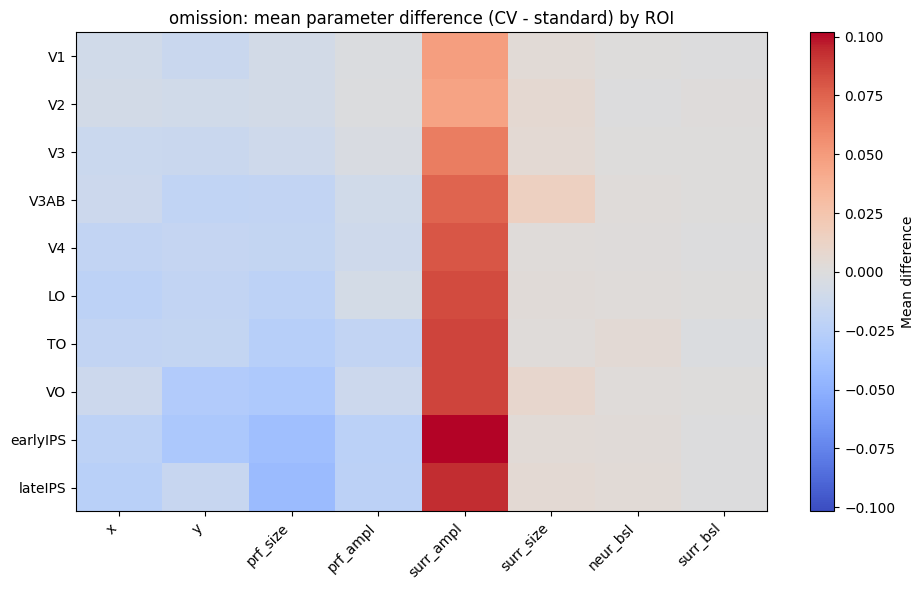

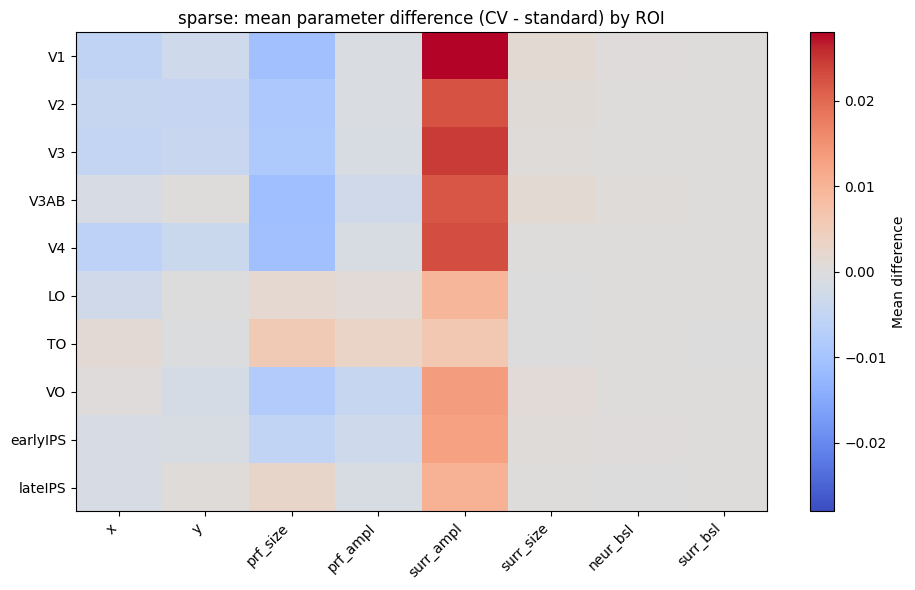

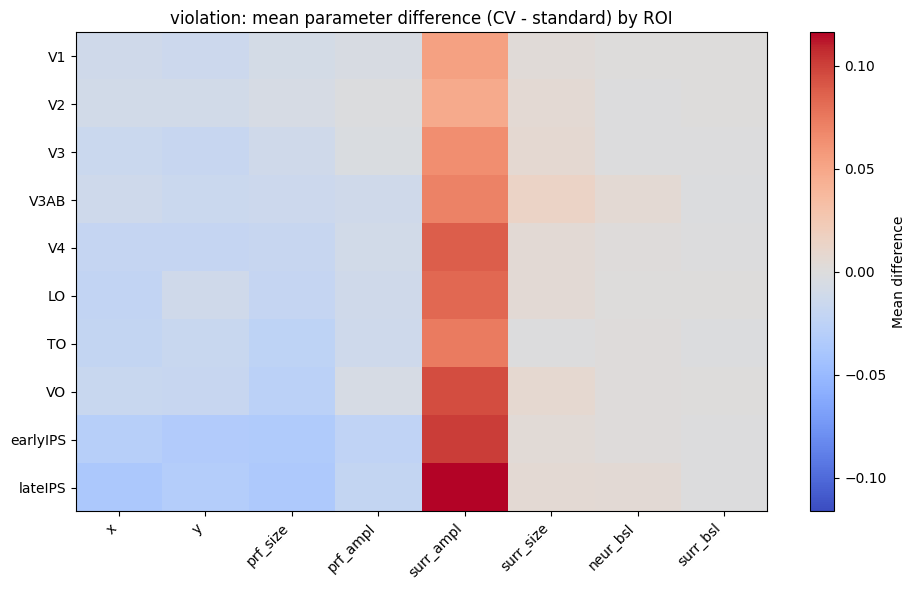

In [5]:
# Heatmaps of ROI-wise parameter differences: (CV - standard) for each condition
for cond in conditions:
    delta_table = (
        comparison_summary_df[comparison_summary_df["condition"] == cond]
        .pivot(index="roi", columns="parameter", values="cv_minus_standard_mean")
        .reindex(index=ROIs_list, columns=params_of_interest)
    )

    delta_values = delta_table.to_numpy(dtype=float)
    finite_vals = delta_values[np.isfinite(delta_values)]
    vmax = np.nanmax(np.abs(finite_vals)) if finite_vals.size else 1.0
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    fig, ax = plt.subplots(figsize=(1.2 * len(params_of_interest), 0.4 * len(ROIs_list) + 2))
    im = ax.imshow(delta_values, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_xticks(np.arange(len(params_of_interest)))
    ax.set_xticklabels(params_of_interest, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(ROIs_list)))
    ax.set_yticklabels(ROIs_list)
    ax.set_title(f"{cond}: mean parameter difference (CV - standard) by ROI")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Mean difference")
    plt.tight_layout()

# Example: inspect one parameter in a tidy table
comparison_summary_df[comparison_summary_df["parameter"] == "prf_size"].sort_values(
    ["roi", "condition"]
)

Binning setup -> n_bins: 5, min_vertices_per_bin: 80
Size unit: cm
Subplot size (cm): (4.0, 4.0)
Manual figure size (cm): (20.0, 20.0)
Using manual figure_size; subplot_size does not control final figure size.
Spacing -> wspace: 0.02, hspace: 0.02
Margins -> left: 0.03, right: 0.88, bottom: 0.05, top: 0.95
ROIs (columns): ['V1', 'V2', 'V3', 'V3AB', 'V4', 'LO', 'TO', 'VO', 'earlyIPS', 'lateIPS']
Parameters (rows): ('x', 'y', 'prf_size', 'prf_ampl', 'surr_ampl', 'surr_size', 'neur_bsl', 'surr_bsl')
Plot order: ['violation', 'omission', 'sparse']
Total binned points: 7800


,subject,roi,parameter,condition,bin,n_vertices,standard_bin_mean,cv_bin_mean
0,sub-001,V1,x,omission,0,612,-3.284075,-3.281406
1,sub-001,V1,x,omission,1,612,-0.883722,-0.901679
2,sub-001,V1,x,omission,2,611,0.155383,0.133876
3,sub-001,V1,x,omission,3,612,0.998654,0.987590
4,sub-001,V1,x,omission,4,612,3.283975,3.270916
5,sub-001,V1,x,sparse,0,612,-3.284075,-3.302654
6,sub-001,V1,x,sparse,1,612,-0.883722,-0.898107
7,sub-001,V1,x,sparse,2,611,0.155383,0.150223
8,sub-001,V1,x,sparse,3,612,0.998654,0.995563
9,sub-001,V1,x,sparse,4,612,3.283975,3.275382


,roi,parameter,condition,standard_mean,cv_mean,n_subjects,n_bins
0,LO,neur_bsl,omission,99.960421,99.962543,7,35
1,TO,neur_bsl,omission,47.112716,47.117488,5,25
2,V1,neur_bsl,omission,251.727998,251.728216,7,35
3,V2,neur_bsl,omission,209.795265,209.795149,7,35
4,V3,neur_bsl,omission,164.269218,164.269794,7,35
5,V3AB,neur_bsl,omission,120.554948,120.556978,7,35
6,V4,neur_bsl,omission,134.110320,134.111399,7,35
7,VO,neur_bsl,omission,101.945619,101.947747,6,30
8,earlyIPS,neur_bsl,omission,76.715646,76.718306,7,35
9,lateIPS,neur_bsl,omission,60.332916,60.336416,5,25


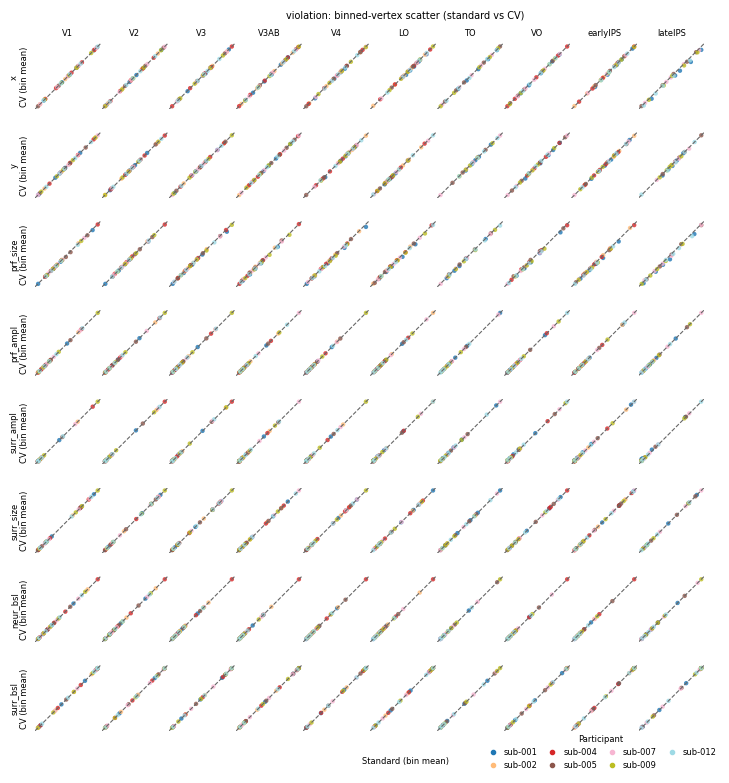

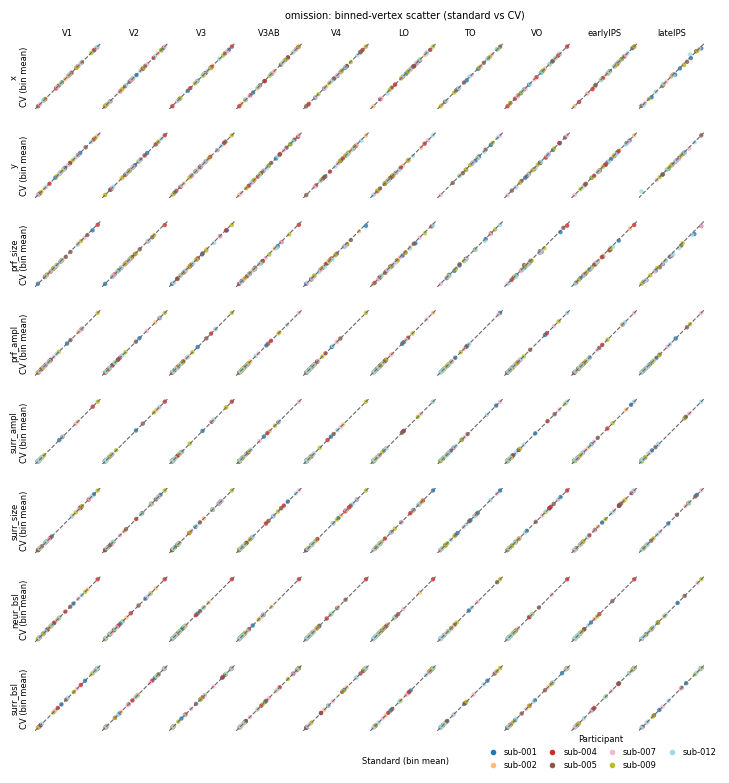

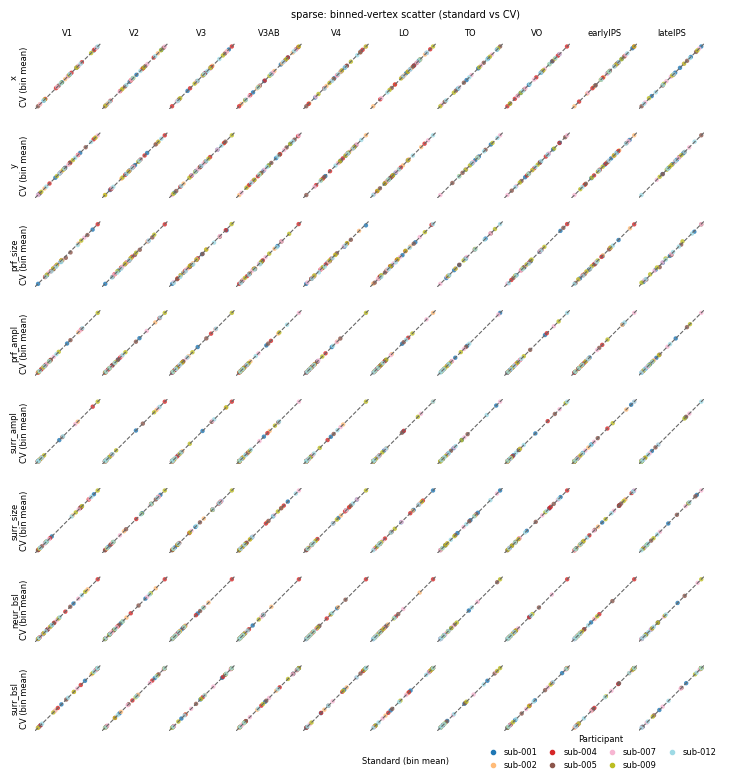

In [33]:
# Binned-vertex scatter: 3 condition figures, parameter rows, all combined ROI columns
from matplotlib.lines import Line2D

# Force all combined ROIs as columns for this plot
rois_for_scatter = tuple(rois.keys())
xy_params = tuple(globals().get("xy_params", ("x", "y")))
pct_params_for_scatter = tuple(
    globals().get(
        "pct_params_for_scatter",
        tuple(p for p in params_of_interest if p not in xy_params),
    )
)

# Larger bins by default: fewer bins and more vertices per bin
scatter_n_bins = int(globals().get("scatter_n_bins", 5))
min_vertices_per_bin = int(globals().get("min_vertices_per_bin", 80))

# Manual size controls
size_unit = str(globals().get("size_unit", "cm")).strip().lower()
subplot_size = globals().get("subplot_size", (1.5, 1.5))
figure_size = globals().get("figure_size", None)
figure_padding = globals().get("figure_padding", (1.0, 0.8))

# Manual spacing controls (reduce blanks between subplots)
subplot_wspace = float(globals().get("subplot_wspace", 0.01))
subplot_hspace = float(globals().get("subplot_hspace", 0.02))
margin_left = float(globals().get("margin_left", 0.20))
margin_right = float(globals().get("margin_right", 0.70))
margin_bottom = float(globals().get("margin_bottom", 0.05))
margin_top = float(globals().get("margin_top", 0.95))
show_subplot_box = bool(globals().get("show_subplot_box", False))

if isinstance(figure_size, str) and figure_size.strip().lower() in ("auto", "none", ""):
    figure_size = None

if scatter_n_bins < 2:
    raise ValueError("scatter_n_bins must be >= 2.")
if min_vertices_per_bin < 1:
    raise ValueError("min_vertices_per_bin must be >= 1.")
if size_unit not in ("inch", "in", "cm", "centimeter", "centimeters"):
    raise ValueError('size_unit must be one of: "inch", "in", or "cm".')
if not (0.0 <= subplot_wspace <= 1.0 and 0.0 <= subplot_hspace <= 1.0):
    raise ValueError("subplot_wspace and subplot_hspace must be between 0 and 1.")
if not (0.0 <= margin_left < margin_right <= 1.0):
    raise ValueError("Margins must satisfy 0 <= margin_left < margin_right <= 1.")
if not (0.0 <= margin_bottom < margin_top <= 1.0):
    raise ValueError("Margins must satisfy 0 <= margin_bottom < margin_top <= 1.")

valid_rois = [roi for roi in rois_for_scatter if roi in rois]
if not valid_rois:
    raise ValueError(
        f"None of rois_for_scatter are in available ROIs. Available: {list(rois.keys())}"
    )

valid_xy_params = tuple(p for p in xy_params if p in params_of_interest)
valid_pct_params = tuple(
    p for p in pct_params_for_scatter if p in params_of_interest and p not in valid_xy_params
)
selected_params = tuple(
    p for p in params_of_interest if p in (set(valid_xy_params) | set(valid_pct_params))
)
if len(selected_params) == 0:
    raise ValueError("No valid parameters selected for plotting.")

def _to_inches(value):
    value = float(value)
    if size_unit in ("cm", "centimeter", "centimeters"):
        return value / 2.54
    return value

def _parse_size_pair(value, name):
    if np.isscalar(value):
        v = float(value)
        return v, v
    if len(value) != 2:
        raise ValueError(f"{name} must be a scalar or a length-2 tuple/list.")
    return float(value[0]), float(value[1])

subplot_w, subplot_h = _parse_size_pair(subplot_size, "subplot_size")
if subplot_w <= 0 or subplot_h <= 0:
    raise ValueError("subplot_size values must be > 0.")
subplot_w_in = _to_inches(subplot_w)
subplot_h_in = _to_inches(subplot_h)

if figure_size is None:
    pad_w, pad_h = _parse_size_pair(figure_padding, "figure_padding")
    if pad_w < 0 or pad_h < 0:
        raise ValueError("figure_padding values must be >= 0.")
    fig_w_in = subplot_w_in * len(valid_rois) + _to_inches(pad_w)
    fig_h_in = subplot_h_in * len(selected_params) + _to_inches(pad_h)
else:
    fig_w, fig_h = _parse_size_pair(figure_size, "figure_size")
    if fig_w <= 0 or fig_h <= 0:
        raise ValueError("figure_size values must be > 0.")
    fig_w_in = _to_inches(fig_w)
    fig_h_in = _to_inches(fig_h)

if len(subjects) <= 20:
    palette = plt.get_cmap("tab20", len(subjects))
else:
    palette = plt.get_cmap("gist_ncar", len(subjects))
subject_colors = {subject: palette(i) for i, subject in enumerate(subjects)}

def _collect_binned_rows(parameters):
    rows = []
    if len(parameters) == 0:
        return pd.DataFrame(
            columns=[
                "subject",
                "roi",
                "parameter",
                "condition",
                "bin",
                "n_vertices",
                "standard_bin_mean",
                "cv_bin_mean",
            ]
        )

    for subject in subjects:
        n_vertices = standard_param_by_subject[subject][parameters[0]].shape[0]
        for roi in valid_rois:
            verts = rois[roi].astype(int)
            verts = verts[(verts >= 0) & (verts < n_vertices)]
            if verts.size == 0:
                continue

            for parameter in parameters:
                std_vals = standard_param_by_subject[subject][parameter][verts]
                for cond in conditions:
                    cv_vals = cv_param_by_subject[cond][subject][parameter][verts]

                    valid = np.isfinite(std_vals) & np.isfinite(cv_vals)
                    if valid.sum() < min_vertices_per_bin:
                        continue

                    std_valid = std_vals[valid]
                    cv_valid = cv_vals[valid]

                    quantiles = np.linspace(0.0, 1.0, scatter_n_bins + 1)
                    edges = np.unique(np.quantile(std_valid, quantiles))
                    if edges.size < 2:
                        continue

                    bin_idx = np.digitize(std_valid, bins=edges[1:-1], right=True)
                    for bin_i in range(edges.size - 1):
                        in_bin = bin_idx == bin_i
                        n_bin = int(in_bin.sum())
                        if n_bin < min_vertices_per_bin:
                            continue

                        std_bin_mean = np.nanmean(std_valid[in_bin])
                        cv_bin_mean = np.nanmean(cv_valid[in_bin])
                        if not np.isfinite(std_bin_mean) or not np.isfinite(cv_bin_mean):
                            continue

                        rows.append(
                            {
                                "subject": subject,
                                "roi": roi,
                                "parameter": parameter,
                                "condition": cond,
                                "bin": bin_i,
                                "n_vertices": n_bin,
                                "standard_bin_mean": std_bin_mean,
                                "cv_bin_mean": cv_bin_mean,
                            }
                        )

    return pd.DataFrame(rows)

def _panel_limits(panel):
    if panel.empty:
        return -1.0, 1.0
    vals = np.concatenate(
        [
            panel["standard_bin_mean"].to_numpy(dtype=float),
            panel["cv_bin_mean"].to_numpy(dtype=float),
        ]
    )
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return -1.0, 1.0
    low = float(np.nanmin(vals))
    high = float(np.nanmax(vals))
    span = high - low
    pad = 0.05 * span if span > 0 else 1.0
    return low - pad, high + pad

def _plot_panel(ax, panel):
    low, high = _panel_limits(panel)
    if panel.empty:
        ax.text(
            0.5,
            0.5,
            "no bins",
            ha="center",
            va="center",
            fontsize=6,
            transform=ax.transAxes,
        )
    else:
        for subject in subjects:
            subj_panel = panel[panel["subject"] == subject]
            if subj_panel.empty:
                continue
            ax.scatter(
                subj_panel["standard_bin_mean"],
                subj_panel["cv_bin_mean"],
                s=10,
                alpha=0.8,
                color=subject_colors[subject],
                edgecolor="none",
            )

    ax.plot([low, high], [low, high], linestyle="--", color="0.4", lw=0.8)
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    if not show_subplot_box:
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_frame_on(False)

xy_scatter_binned_df = _collect_binned_rows(valid_xy_params)
scatter_binned_df = _collect_binned_rows(valid_pct_params)

all_scatter_sources = [df for df in (xy_scatter_binned_df, scatter_binned_df) if not df.empty]
if len(all_scatter_sources) == 0:
    all_scatter_binned_df = pd.DataFrame(
        columns=[
            "subject",
            "roi",
            "parameter",
            "condition",
            "bin",
            "n_vertices",
            "standard_bin_mean",
            "cv_bin_mean",
        ]
    )
else:
    all_scatter_binned_df = pd.concat(
        all_scatter_sources,
        ignore_index=True,
        sort=False,
    )

if all_scatter_binned_df.empty:
    all_scatter_binned_summary_df = pd.DataFrame()
else:
    all_scatter_binned_summary_df = (
        all_scatter_binned_df.groupby(["roi", "parameter", "condition"], as_index=False)
        .agg(
            standard_mean=("standard_bin_mean", "mean"),
            cv_mean=("cv_bin_mean", "mean"),
            n_subjects=("subject", "nunique"),
            n_bins=("bin", "count"),
        )
        .sort_values(["condition", "parameter", "roi"] )
        .reset_index(drop=True)
    )

condition_plot_order = ("violation", "omission", "sparse")
plot_conditions = [cond for cond in condition_plot_order if cond in conditions]
plot_conditions.extend([cond for cond in conditions if cond not in plot_conditions])

print(
    f"Binning setup -> n_bins: {scatter_n_bins}, min_vertices_per_bin: {min_vertices_per_bin}"
)
print(f"Size unit: {size_unit}")
print(f"Subplot size ({size_unit}): ({subplot_w}, {subplot_h})")
if figure_size is None:
    print(f"Auto figure size (in): ({fig_w_in:.2f}, {fig_h_in:.2f})")
else:
    print(f"Manual figure size ({size_unit}): ({fig_w}, {fig_h})")
    print("Using manual figure_size; subplot_size does not control final figure size.")
print(f"Spacing -> wspace: {subplot_wspace}, hspace: {subplot_hspace}")
print(
    f"Margins -> left: {margin_left}, right: {margin_right}, "
    f"bottom: {margin_bottom}, top: {margin_top}"
)
print(f"ROIs (columns): {valid_rois}")
print(f"Parameters (rows): {selected_params}")
print(f"Plot order: {plot_conditions}")
print(f"Total binned points: {len(all_scatter_binned_df)}")

if all_scatter_binned_df.empty:
    print("No standard-vs-CV panels were generated.")
else:
    n_rows = len(selected_params)
    n_cols = len(valid_rois)

    panel_lookup = {
        key: grp
        for key, grp in all_scatter_binned_df.groupby(["condition", "parameter", "roi"], sort=False)
    }

    for cond in plot_conditions:
        fig = plt.figure(figsize=(fig_w_in, fig_h_in))

        for row_i, parameter in enumerate(selected_params):
            for col_i, roi in enumerate(valid_rois):
                panel_idx = row_i * n_cols + col_i + 1
                ax = plt.subplot(n_rows, n_cols, panel_idx)
                panel = panel_lookup.get((cond, parameter, roi), pd.DataFrame())
                _plot_panel(ax, panel)

                if row_i == 0:
                    ax.set_title(roi, fontsize=6)
                if col_i == 0:
                    ax.set_ylabel(f"{parameter}\nCV (bin mean)", fontsize=6)

        legend_handles = [
            Line2D(
                [],
                [],
                marker="o",
                linestyle="",
                markersize=3,
                color=subject_colors[s],
                label=s,
            )
            for s in subjects
        ]

        n_legend_rows = 2
        legend_ncols = int(np.ceil(len(legend_handles) / n_legend_rows))

        fig.legend(
            handles=legend_handles,
            title="Participant",
            loc="lower right",
            bbox_to_anchor=(0.90, 0.01),
            ncol=legend_ncols,
            frameon=False,
            fontsize=6,
            title_fontsize=6,
            columnspacing=0.8,
            handletextpad=0.3,
            borderaxespad=0.0,
        )

        fig.subplots_adjust(
            left=margin_left,
            right=margin_right,
            bottom=margin_bottom,
            top=margin_top,
            wspace=subplot_wspace,
            hspace=subplot_hspace,
        )
        fig.suptitle(
            f"{cond}: binned-vertex scatter (standard vs CV)",
            y=min(0.995, margin_top + 0.03),
            fontsize=7,
        )
        fig.supxlabel(
            "Standard (bin mean)",
            fontsize=6,
            y=max(0.005, margin_bottom - 0.03),
        )

display(all_scatter_binned_df.head(20))
display(all_scatter_binned_summary_df.head(20))